# Activity 2: Web Scraping with Python
### eMathrix Education — Data Science & Data Analytics

Today you'll learn **web scraping**, pulling data straight off a web page with code, then a first taste of **data cleaning**, then analysis.

We'll scrape the **Laguna Open Data Portal**, a live web page with three tables: weather stations, schools, and tourism sites.

**The page we'll scrape:** https://datasciencebaguio-production.up.railway.app/datasets/laguna_data

**Important and honest:** this portal holds **simulated sample data** made for this workshop. The numbers are realistic but invented, they are not official government figures. What's real here is the *skill*: this is exactly how you'd scrape and clean tables from a real government open-data page.

Run each cell with **Shift + Enter**, top to bottom.

## Step 1: Install the scraping tools

In [1]:
!pip install beautifulsoup4 requests

## Step 2: Load the libraries

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("Libraries loaded.")

Libraries loaded.


## Step 3: Download the web page

`requests.get` fetches the raw page from the portal. A status of **200** means success.

In [3]:
url = 'https://datasciencebaguio-production.up.railway.app/datasets/laguna_data'

try:
    response = requests.get(url, timeout=15)
    print(f"Status code: {response.status_code}")
    if response.status_code == 200:
        print("Page downloaded successfully.")
    else:
        print("Got a response, but not 200. The site may be busy.")
except Exception as e:
    print(f"Could not reach the site: {e}")
    print("Check your internet connection and try again.")

Status code: 200
Page downloaded successfully.


## Step 4: Parse the HTML and look at the page

`BeautifulSoup` turns the raw HTML into something we can search. Let's read the page title, the notice, and count how many tables are on the page.

In [4]:
soup = BeautifulSoup(response.text, 'html.parser')

print("Page heading:", soup.find('h1').text)

notice = soup.find('p')
if notice:
    print("\nNotice on the page:")
    print(" ", notice.text.strip())

tables_on_page = soup.find_all('table')
print(f"\nThis page has {len(tables_on_page)} tables.")

print("\nSection titles found:")
for h2 in soup.find_all('h2'):
    print(" -", h2.text)

Page heading: Laguna Provincial Open Data Portal

Notice on the page:
  Note: This is SIMULATED sample data created for a data science training workshop. The numbers are generated for practice and do not represent official government statistics. Elevation values are illustrative sample numbers.

This page has 3 tables.

Section titles found:
 - Weather Stations
 - Schools and Enrollment
 - Tourism and Cultural Sites


## Step 5: Scrape all three tables at once

`pd.read_html` reads every table on the page into a list. The page has three, so we get three DataFrames.

In [5]:
tables = pd.read_html(response.text)
print(f"Scraped {len(tables)} tables from the page.\n")

weather_df = tables[0]
schools_df = tables[1]
tourism_df = tables[2]

print(f"Weather stations: {len(weather_df)} rows")
print(f"Schools: {len(schools_df)} rows")
print(f"Tourism sites: {len(tourism_df)} rows")

/tmp/ipykernel_1156/2462685539.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Scraped 3 tables from the page.

Weather stations: 47 rows
Schools: 51 rows
Tourism sites: 40 rows


## Step 6: Look at what we scraped

Always eyeball your data before analyzing it.

In [6]:
print("WEATHER STATIONS (first 5):")
display(weather_df.head())
print("SCHOOLS (first 5):")
display(schools_df.head())
print("TOURISM SITES (first 5):")
display(tourism_df.head())

WEATHER STATIONS (first 5):


,Station ID,Location,Province,Temperature_C,Humidity_pct,Rainfall_mm,Condition,Elevation_m
0,WS001,Calamba,Laguna,15,61.0,17.0,Partly Cloudy,1064
1,WS002,Pangil,Laguna,16,66.0,43.0,Foggy,2383
2,WS003,Rizal,Laguna,15,NaN,NaN,Sunny,533
3,WS004,Los Baños,Laguna,17,74.0,32.0,Moderate Rain,258
4,WS005,Calauan,Laguna,22,72.0,45.0,Foggy,2382


SCHOOLS (first 5):


,School ID,School Name,Municipality,Province,Type,Enrollment,Teachers,Student_Teacher_Ratio,Year_Established
0,SCH0001,Saint Pagsanjan Institute,Pagsanjan,Laguna,College,1329,52.0,25.6,2000.0
1,SCH0002,Saint Mabitac Institute,Mabitac,Laguna,College,771,29.0,26.6,1998.0
2,SCH0003,San Los Baños Institute,Los Baños,Laguna,High School,414,21.0,19.7,1978.0
3,SCH0004,North Nagcarlan Academy,Nagcarlan,Laguna,High School,297,NaN,18.6,NaN
4,SCH0005,San Victoria Institute,Victoria,Laguna,Elementary,167,8.0,20.9,2017.0


TOURISM SITES (first 5):


,Site ID,Site Name,Location,Province,Type,Annual_Visitors,Entry_Fee_PHP,Rating,Accessibility
0,TOU001,Paete Shrine,Paete,Laguna,Religious,6367,0,3.9,Difficult
1,TOU002,San Pablo Monument,San Pablo,Laguna,Historical,43607,0,4.6,Difficult
2,TOU003,Calamba Museum,Calamba,Laguna,Cultural,2335,150,3.3,Easy
3,TOU004,Liliw Rice Terraces,Liliw,Laguna,Natural,15284,100,4.4,Moderate
4,TOU005,Pagsanjan Heritage Village,Pagsanjan,Laguna,Cultural,8084,150,3.1,Moderate


## Step 7: Check the data quality

Real scraped data is rarely perfect. Before analyzing, check each table for **missing values** (empty cells) and **duplicate rows**.

In [7]:
for name, df in [('WEATHER', weather_df), ('SCHOOLS', schools_df), ('TOURISM', tourism_df)]:
    print(f"{name}: {df.isnull().sum().sum()} missing cells, {df.duplicated().sum()} duplicate rows")

print("\nMissing cells per column (weather):")
print(weather_df.isnull().sum()[weather_df.isnull().sum() > 0])

print("\nMissing cells per column (schools):")
print(schools_df.isnull().sum()[schools_df.isnull().sum() > 0])

WEATHER: 8 missing cells, 1 duplicate rows
SCHOOLS: 8 missing cells, 1 duplicate rows
TOURISM: 0 missing cells, 0 duplicate rows

Missing cells per column (weather):
Humidity_pct    3
Rainfall_mm     3
Condition       2
dtype: int64

Missing cells per column (schools):
Type                2
Teachers            3
Year_Established    3
dtype: int64


## Step 8: A first pass at cleaning

The tourism table is already clean, but **weather** and **schools** have a few empty cells and a duplicate row. Let's do a light, sensible clean-up:

1. **Remove duplicate rows** (the exact same record appearing twice).
2. **Fill missing numbers** with the column **average** (a simple, common choice).
3. **Fill missing text** with the **most common value** (the mode).

This is just a *first pass*. Real, full cleaning (checking outliers, fixing data types, validating values) is a bigger topic we'll go deeper into later.

In [8]:
# 1) Remove duplicate rows
weather_df = weather_df.drop_duplicates().copy()
schools_df = schools_df.drop_duplicates().copy()

# 2) Fill missing NUMBERS with the column average
for col in ['Humidity_pct', 'Rainfall_mm']:
    weather_df[col] = weather_df[col].fillna(round(weather_df[col].mean()))
schools_df['Teachers'] = schools_df['Teachers'].fillna(round(schools_df['Teachers'].mean()))
schools_df['Year_Established'] = schools_df['Year_Established'].fillna(schools_df['Year_Established'].median())

# 3) Fill missing TEXT with the most common value (mode)
weather_df['Condition'] = weather_df['Condition'].fillna(weather_df['Condition'].mode()[0])
schools_df['Type'] = schools_df['Type'].fillna(schools_df['Type'].mode()[0])

print("After the first cleaning pass:")
for name, df in [('WEATHER', weather_df), ('SCHOOLS', schools_df), ('TOURISM', tourism_df)]:
    print(f"  {name}: {len(df)} rows, {df.isnull().sum().sum()} missing cells, {df.duplicated().sum()} duplicates")

print("\nNote: this is a first pass only. Full cleaning comes later.")

After the first cleaning pass:
  WEATHER: 46 rows, 0 missing cells, 0 duplicates
  SCHOOLS: 50 rows, 0 missing cells, 0 duplicates
  TOURISM: 40 rows, 0 missing cells, 0 duplicates

Note: this is a first pass only. Full cleaning comes later.


## Step 9: Quick summary numbers

Now that the data is tidied up, a few headline figures from each table.

In [9]:
print("WEATHER")
print(f"  Average temperature: {weather_df['Temperature_C'].mean():.1f} C")
print(f"  Average rainfall: {weather_df['Rainfall_mm'].mean():.1f} mm")

print("\nSCHOOLS")
print(f"  Total enrollment: {schools_df['Enrollment'].sum():,} students")
print(f"  Average class ratio: {schools_df['Student_Teacher_Ratio'].mean():.1f} students per teacher")

print("\nTOURISM")
print(f"  Total annual visitors: {tourism_df['Annual_Visitors'].sum():,}")
print(f"  Average rating: {tourism_df['Rating'].mean():.2f} out of 5")

WEATHER
  Average temperature: 24.0 C
  Average rainfall: 23.2 mm

SCHOOLS
  Total enrollment: 31,662 students
  Average class ratio: 23.2 students per teacher

TOURISM
  Total annual visitors: 1,042,841
  Average rating: 4.00 out of 5


## Step 10: Correlation between two variables

A **correlation** tells us if two number columns move together. It ranges from **-1 to +1**: near **+1** they rise together, near **-1** one rises as the other falls, near **0** there's no clear relationship.

Let's check **elevation** vs **temperature** in the weather data. In real life we'd expect higher places to be cooler (a negative correlation). Remember our data is randomly simulated, so the result will likely sit near 0 — which is itself the honest lesson: the number tells you the truth, not your guess.

Correlation between Elevation_m and Temperature_C: -0.376
That's a weak relationship (close to zero).


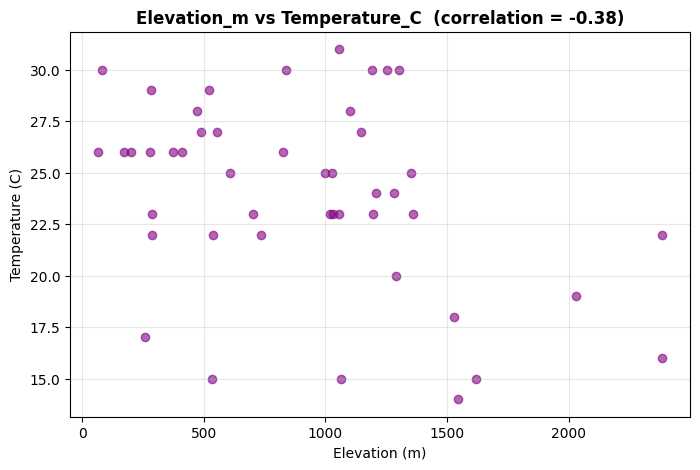

In [10]:
x = 'Elevation_m'
y = 'Temperature_C'

r = weather_df[x].corr(weather_df[y])
print(f"Correlation between {x} and {y}: {r:.3f}")

if r > 0.5:
    print("That's a fairly strong POSITIVE relationship.")
elif r < -0.5:
    print("That's a fairly strong NEGATIVE relationship.")
else:
    print("That's a weak relationship (close to zero).")

plt.figure(figsize=(8, 5))
plt.scatter(weather_df[x], weather_df[y], alpha=0.6, color='purple')
plt.title(f'{x} vs {y}  (correlation = {r:.2f})', fontweight='bold')
plt.xlabel('Elevation (m)')
plt.ylabel('Temperature (C)')
plt.grid(alpha=0.3)
plt.show()

## Step 11: The analysis dashboard

Six charts in one figure, pulling from all three cleaned tables.

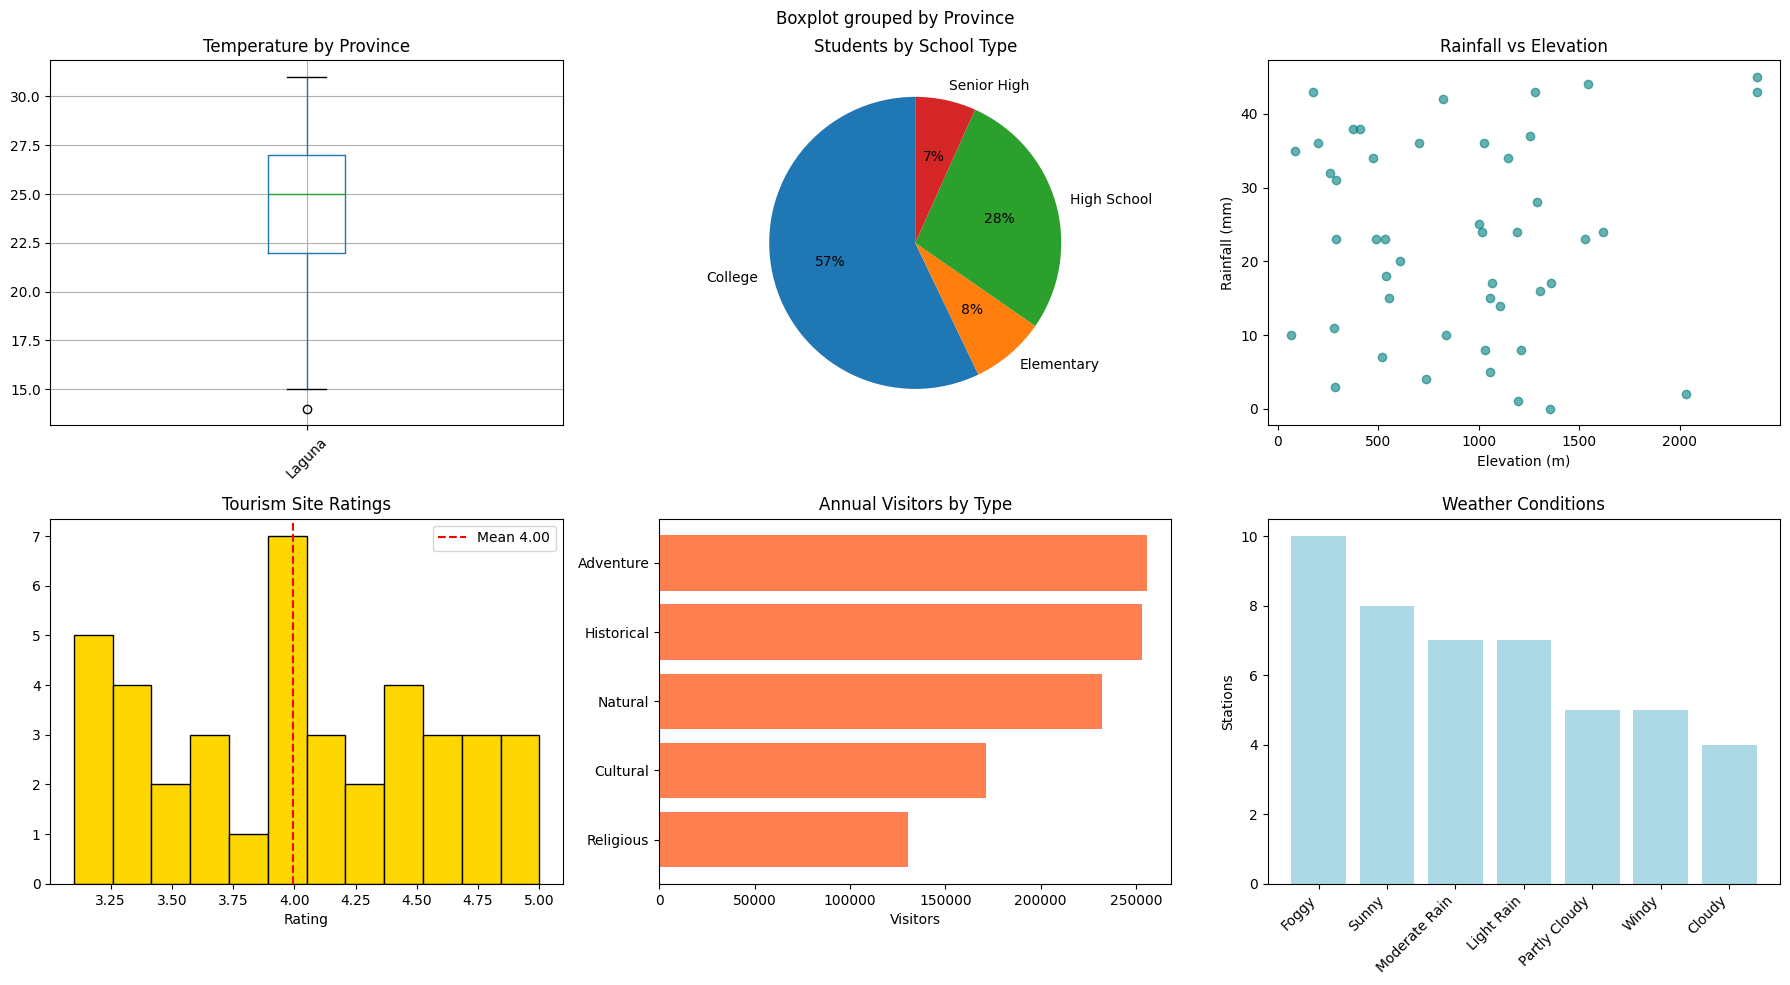

Dashboard built from the scraped and cleaned Laguna data.


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Laguna Data Dashboard (Simulated Sample Data)', fontsize=15, fontweight='bold')

# 1. Temperature by province
weather_df.boxplot(column='Temperature_C', by='Province', ax=axes[0, 0])
axes[0, 0].set_title('Temperature by Province')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Students by school type
by_type = schools_df.groupby('Type')['Enrollment'].sum()
axes[0, 1].pie(by_type.values, labels=by_type.index, autopct='%1.0f%%', startangle=90)
axes[0, 1].set_title('Students by School Type')

# 3. Rainfall vs elevation
axes[0, 2].scatter(weather_df['Elevation_m'], weather_df['Rainfall_mm'], alpha=0.6, color='teal')
axes[0, 2].set_title('Rainfall vs Elevation')
axes[0, 2].set_xlabel('Elevation (m)')
axes[0, 2].set_ylabel('Rainfall (mm)')

# 4. Tourism ratings
axes[1, 0].hist(tourism_df['Rating'], bins=12, color='gold', edgecolor='black')
axes[1, 0].axvline(tourism_df['Rating'].mean(), color='red', linestyle='--',
                   label=f"Mean {tourism_df['Rating'].mean():.2f}")
axes[1, 0].set_title('Tourism Site Ratings')
axes[1, 0].set_xlabel('Rating')
axes[1, 0].legend()

# 5. Visitors by tourism type
by_t = tourism_df.groupby('Type')['Annual_Visitors'].sum().sort_values()
axes[1, 1].barh(by_t.index, by_t.values, color='coral')
axes[1, 1].set_title('Annual Visitors by Type')
axes[1, 1].set_xlabel('Visitors')

# 6. Weather conditions
cond = weather_df['Condition'].value_counts()
axes[1, 2].bar(range(len(cond)), cond.values, color='lightblue')
axes[1, 2].set_xticks(range(len(cond)))
axes[1, 2].set_xticklabels(cond.index, rotation=45, ha='right')
axes[1, 2].set_title('Weather Conditions')
axes[1, 2].set_ylabel('Stations')

plt.tight_layout()
plt.show()
print("Dashboard built from the scraped and cleaned Laguna data.")

---
### What you learned

You scraped a **live web page** with three tables, did a **first pass of data cleaning** (removed duplicates, filled missing values), and analyzed the result, the core loop of real data collection.

Three honest notes to remember: always check a site's terms before scraping it; always be clear about whether your data is real or simulated; and remember today's cleaning was just a *first taste* — full cleaning is a deeper skill we'll build on later.

Mahaba pa ang pwedeng gawin sa scraping at cleaning. Tanong lang kung gusto nyo ng mas malalim.

— eMathrix Education · Data Science & Data Analytics